<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

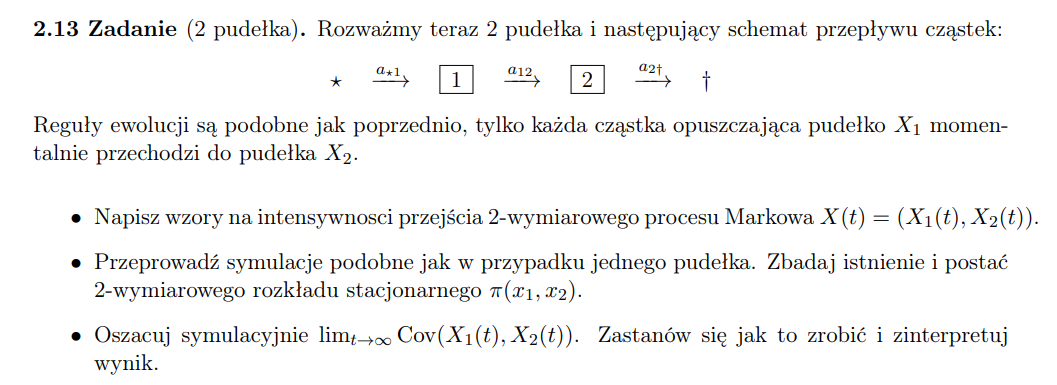

### Intensities of transitions
---

Let us denote our 2-dimensional Markov process as $X(t)=(x_1, x_2)$. Obtaining the intensities of transistions is straightforward:

$$q_{(x_1,x_2) → (x_1+1,x_2)} = a_{\star1}$$
$$q_{(x_1,x_2) → (x_1-1,x_2+1)} = x_1 a_{12}$$
$$q_{(x_1,x_2) → (x_1,x_2-1)} = x_2 a_{2\dagger}$$
$$q_{(x_1,x_2) → (x_1,x_2)} = -(a_{\star1}+x_1 a_{12}+x_2 a_{2\dagger})$$

### Simulations
----

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
def gillespie_sampler(a_star1, a_12, a_2dagger, X1_0, X2_0, T_max):
    t = [0.0]
    X1 = [X1_0]
    X2 = [X2_0]

    while t[-1] < T_max:
        current_X1 = X1[-1]
        current_X2 = X2[-1]

        # updating intensivities
        rate_in = a_star1
        rate_transfer = current_X1 * a_12
        rate_out = current_X2 * a_2dagger

        total_rate = rate_in + rate_transfer + rate_out

        if total_rate == 0:
            break

        # sampling moments of events
        dt = np.random.exponential(1.0 / total_rate)
        t.append(t[-1] + dt)

        u = np.random.rand()

        # sampling type of event
        if u < rate_in / total_rate:
            X1.append(current_X1 + 1)
            X2.append(current_X2)
        elif u < (rate_in + rate_transfer) / total_rate:
            X1.append(current_X1 - 1)
            X2.append(current_X2 + 1)
        else:
            X1.append(current_X1)
            X2.append(current_X2 - 1)

    # cutting at T_max
    if t[-1] > T_max:
        t[-1] = T_max
        X1[-1] = X1[-2]
        X2[-1] = X2[-2]

    return np.array(t), np.array(X1), np.array(X2)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11379/4037921720.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Trajectory ($a_\star1={a_star1}, a_12={a_12}, a_2\dagger={a_2dagger}$)')
/tmp/ipykernel_11379/4037921720.py:11: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'Trajectory ($a_\star1={a_star1}, a_12={a_12}, a_2\dagger={a_2dagger}$)')


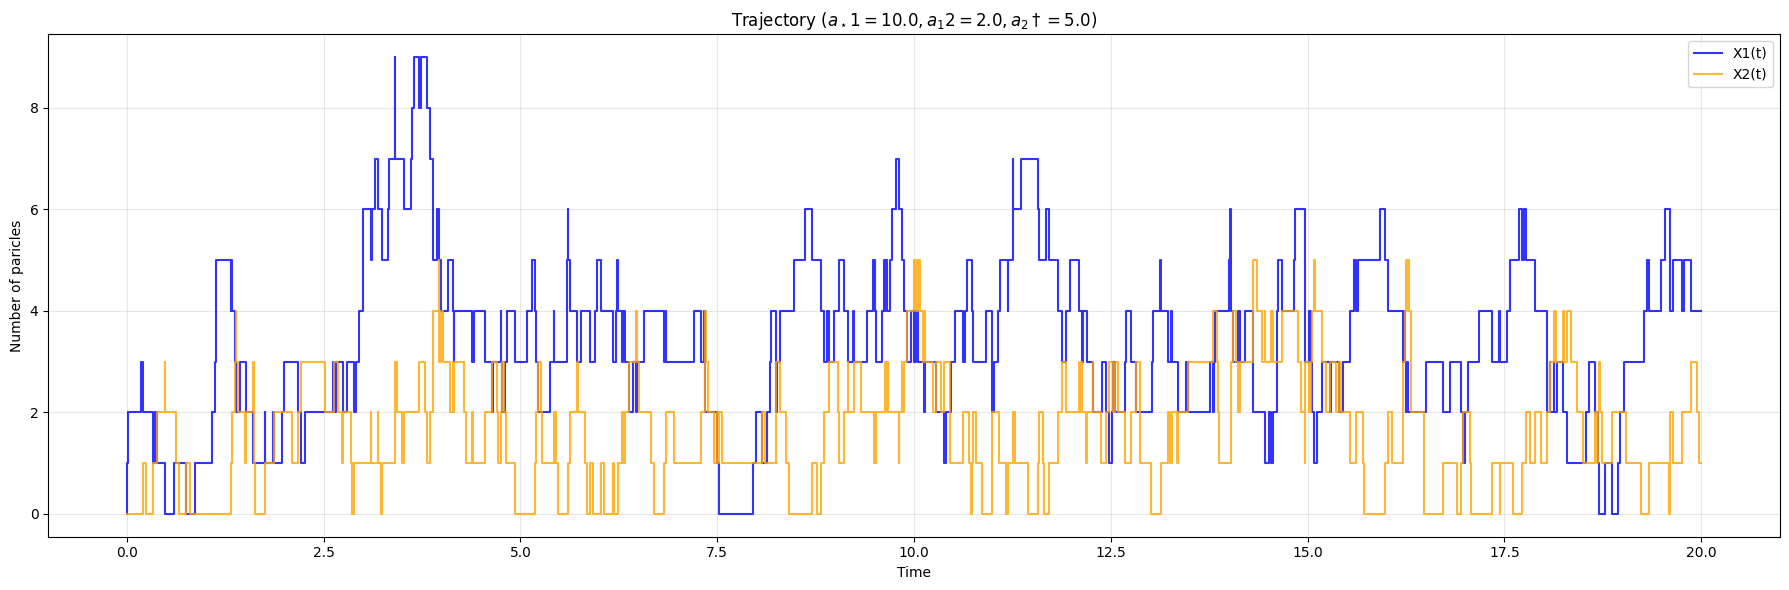

In [8]:
a_star1 = 10.0
a_12 = 2.0
a_2dagger = 5.0
T_max = 20.0

plt.figure(figsize=(18, 6))

t_sim, X1_sim, X2_sim = gillespie_sampler(a_star1, a_12, a_2dagger, X1_0=0, X2_0=0, T_max=T_max)
plt.step(t_sim, X1_sim, where='post', alpha=0.8, color='blue', label='X1(t)')
plt.step(t_sim, X2_sim, where='post', alpha=0.8, color='orange', label='X2(t)')
plt.title(f'Trajectory ($a_\star1={a_star1}, a_12={a_12}, a_2\dagger={a_2dagger}$)')
plt.xlabel('Time')
plt.ylabel('Number of paricles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11379/440087873.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Trajectory ($a_\star1={a_star1}, a_12={a_12}, a_2\dagger={a_2dagger}$)')
/tmp/ipykernel_11379/440087873.py:11: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'Trajectory ($a_\star1={a_star1}, a_12={a_12}, a_2\dagger={a_2dagger}$)')


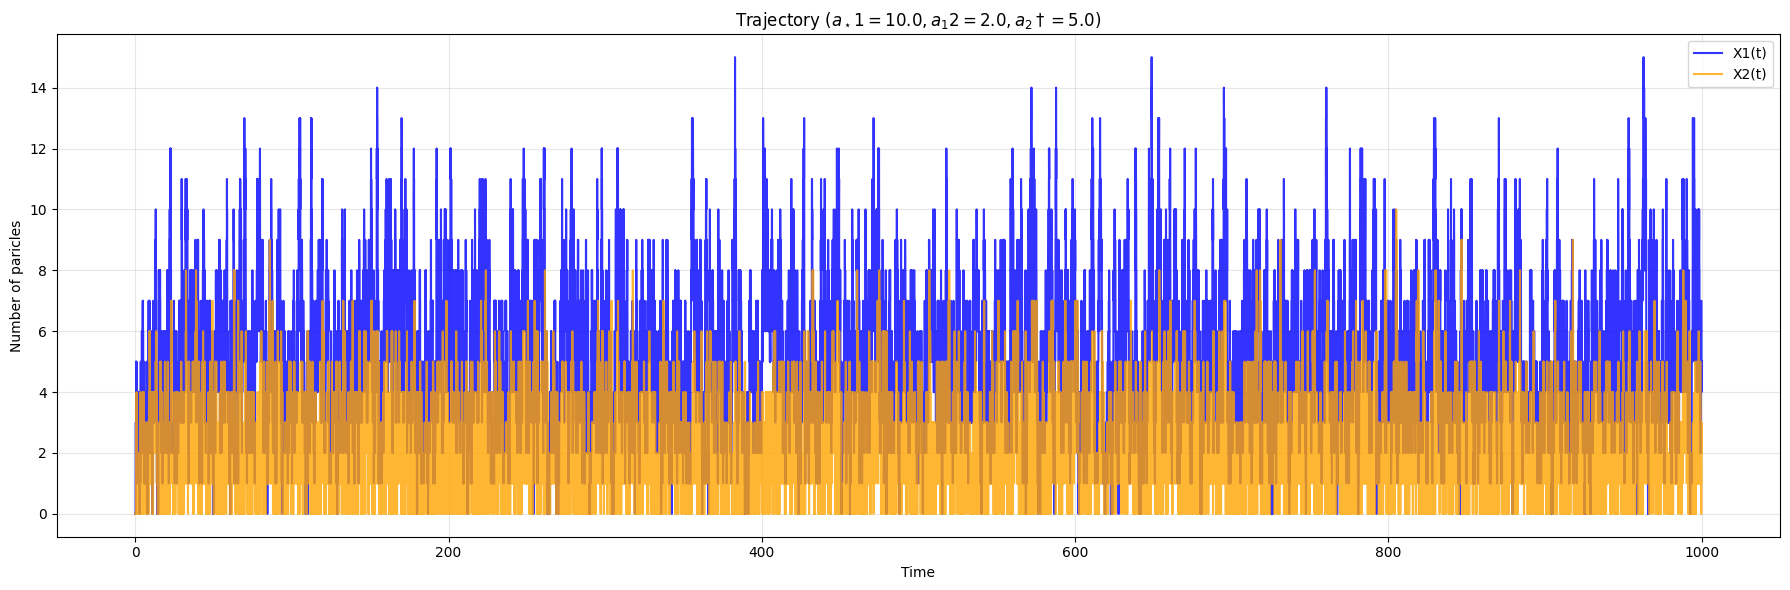

In [11]:
a_star1 = 10.0
a_12 = 2.0
a_2dagger = 5.0
T_max = 1000.0

plt.figure(figsize=(18, 6))

t_sim, X1_sim, X2_sim = gillespie_sampler(a_star1, a_12, a_2dagger, X1_0=0, X2_0=0, T_max=T_max)
plt.step(t_sim, X1_sim, where='post', alpha=0.8, color='blue', label='X1(t)')
plt.step(t_sim, X2_sim, where='post', alpha=0.8, color='orange', label='X2(t)')
plt.title(f'Trajectory ($a_\star1={a_star1}, a_12={a_12}, a_2\dagger={a_2dagger}$)')
plt.xlabel('Time')
plt.ylabel('Number of paricles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
T_long = 100000
t_l, X1_l, X2_l = gillespie_sampler(a_star1, a_12, a_2dagger, X1_0=0, X2_0=0, T_max=T_long)

# holding times
dt = np.diff(t_l)
x1_visited = X1_l[:-1]
x2_visited = X2_l[:-1]

# computing EX1 and EX2
mean_x1 = np.sum(x1_visited * dt) / T_long
mean_x2 = np.sum(x2_visited * dt) / T_long

# computing variances
var_x1 = np.sum(((x1_visited - mean_x1)**2) * dt) / T_long
var_x2 = np.sum(((x2_visited - mean_x2)**2) * dt) / T_long

# computing covariance - E[(X1 - E[X1]) * (X2 - E[X2])] and correlation
cov_x1_x2 = np.sum((x1_visited - mean_x1) * (x2_visited - mean_x2) * dt) / T_long
correlation = cov_x1_x2 / np.sqrt(var_x1 * var_x2)

print("Results:")
print(f"E[X1] = {mean_x1:.4f} (Theoretically: {a_star1/a_12:.4f})")
print(f"E[X2] = {mean_x2:.4f} (Theoretically: {a_star1/a_2dagger:.4f})")
print(f"\nCov(X1, X2) = {cov_x1_x2:.5f}")
print(f"Corr(X1, X2) = {correlation:.5f}")

Results:
E[X1] = 5.0041 (Theoretically: 5.0000)
E[X2] = 1.9985 (Theoretically: 2.0000)

Cov(X1, X2) = 0.00952
Corr(X1, X2) = 0.00300


### Stationary distribution
---
From the simulation, we can observe that the process stabilizes around certain values ($\mathbb{E}X_1 = 5$ and $\mathbb{E}X_2 = 2$). This is a strong indication that the stationary distribution exists. We may also observe that in the stationary state, the two boxes behave as if they were completely independent. Thus, we can rewrite the joint stationary distribution as the product of their marginals:$$\pi(x_1, x_2) = \pi_1(x_1) \pi_2(x_2)$$From the previous exercise (2.12), we know that for a single box, the stationary distribution aligns with the Poisson distribution. Let us analyze:
* Box 1: Particles enter with intensity $a_{\star1}$ and exit with intensity $a_{12}$. Therefore, the parameter for the Poisson distribution is $\lambda_1 = \frac{a_{\star1}}{a_{12}}$.
* Box 2: In equilibrium, the effective stream of particles entering Box 2 is equal to the initial stream entering the system, which is $a_{\star1}$. They exit with intensity $a_{2\dagger}$. Therefore, the parameter for the Poisson distribution is $\lambda_2 = \frac{a_{\star1}}{a_{2\dagger}}$.
Finally, we obtain the formula for the joint stationary distribution:$$\pi(x_1, x_2) = \pi_1(x_1) \pi_2(x_2) = \left( e^{-\frac{a_{\star1}}{a_{12}}} \frac{\left(\frac{a_{\star1}}{a_{12}}\right)^{x_1}}{x_1!} \right) \cdot \left( e^{-\frac{a_{\star1}}{a_{2\dagger}}} \frac{\left( \frac{a_{\star1}}{a_{2\dagger}} \right)^{x_2}}{x_2!} \right)$$
